In [334]:
# importing the data
import pandas as pd
path="/Users/ggharish13/Data Science/Capstone Project/Amazon Music clustering/single_genre_artists.csv"
original_data=pd.read_csv(path)

# dropping duplicates if there
original_data = original_data.drop_duplicates()
original_data=original_data.reset_index(drop=True)
data=original_data.copy()
data.head()

,id_songs,name_song,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists
0,0IA0Hju8CAgYfV1hwhidBH,La Java,0,161427,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.563,0.184,4,...,0.993,0.000016,0.325,0.654,133.088,3,5078.0,['vintage chanson'],Mistinguett,22
1,1b8HZQCqcqwbzlA1jRTp6E,En Douce,0,223440,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.427,0.180,10,...,0.989,0.000000,0.128,0.431,78.459,3,5078.0,['vintage chanson'],Mistinguett,22
2,5d5gQxHwYovxR5pqETOIAa,J'en Ai Marre,0,208267,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.511,0.206,0,...,0.995,0.000000,0.418,0.481,70.443,4,5078.0,['vintage chanson'],Mistinguett,22
3,1EO65UEEPfy7CR0NK2sDxy,Ils n'ont pas ca,0,161933,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.676,0.467,9,...,0.991,0.000000,0.219,0.726,129.775,4,5078.0,['vintage chanson'],Mistinguett,22
4,6a58gXSgqbIsXUhVZ6ZJqe,La belote,0,167973,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.650,0.298,9,...,0.991,0.000000,0.373,0.844,75.950,4,5078.0,['vintage chanson'],Mistinguett,22


In [335]:
# checking how data is been distribute (mean and std)
data.describe()

,popularity_songs,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,popularity_artists
count,95837.000000,9.583700e+04,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,95837.000000,9.583700e+04,95837.000000
mean,26.066394,2.087320e+05,0.029644,0.586853,0.541083,5.196782,-10.157862,0.648069,0.168832,0.458989,0.082145,0.224916,0.574281,117.539870,3.851362,1.979919e+05,42.819329
std,16.254133,1.177526e+05,0.169604,0.155422,0.236304,3.534923,4.748798,0.477575,0.275417,0.330416,0.232440,0.185829,0.248126,30.190399,0.544406,7.807520e+05,20.897833
min,0.000000,6.373000e+03,0.000000,0.000000,0.000020,0.000000,-50.174000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000
25%,13.000000,1.573330e+05,0.000000,0.488000,0.365000,2.000000,-12.723000,0.000000,0.034100,0.133000,0.000000,0.100000,0.378000,94.829000,4.000000,2.563000e+03,28.000000
50%,26.000000,2.040000e+05,0.000000,0.605000,0.542000,5.000000,-9.397000,1.000000,0.046200,0.453000,0.000004,0.149000,0.589000,116.595000,4.000000,1.595600e+04,40.000000
75%,37.000000,2.502670e+05,0.000000,0.700000,0.727000,8.000000,-6.692000,1.000000,0.103000,0.759000,0.001300,0.302000,0.780000,135.975000,4.000000,8.495100e+04,56.000000
max,98.000000,4.800118e+06,1.000000,0.991000,1.000000,11.000000,5.376000,1.000000,0.968000,0.996000,1.000000,0.997000,1.000000,239.906000,5.000000,2.802643e+07,95.000000


In [336]:
# Checking object values have any pattern to contribute (unique and frequency)
data.describe(include=object)

,id_songs,name_song,id_artists,release_date,genres,name_artists
count,95837,95837,95837,95837,95837,95837
unique,95837,85427,18009,10436,3153,17662
top,0IA0Hju8CAgYfV1hwhidBH,Bibi Blocksberg Lied,3meJIgRw7YleJrmbpbJK6S,1983,['hoerspiel'],Die drei ???
freq,1,33,3856,754,8027,3856


In [337]:
# checking Non-Null and data types
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95837 entries, 0 to 95836
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_songs            95837 non-null  object 
 1   name_song           95837 non-null  object 
 2   popularity_songs    95837 non-null  int64  
 3   duration_ms         95837 non-null  int64  
 4   explicit            95837 non-null  int64  
 5   id_artists          95837 non-null  object 
 6   release_date        95837 non-null  object 
 7   danceability        95837 non-null  float64
 8   energy              95837 non-null  float64
 9   key                 95837 non-null  int64  
 10  loudness            95837 non-null  float64
 11  mode                95837 non-null  int64  
 12  speechiness         95837 non-null  float64
 13  acousticness        95837 non-null  float64
 14  instrumentalness    95837 non-null  float64
 15  liveness            95837 non-null  float64
 16  vale

In [338]:
# Since they have unique values and doesnot contribute to our model
data=data.drop(columns=["id_songs","name_song","id_artists","release_date","genres","name_artists"])

In [339]:
# Since they have unique values and doesnot contribute to our model
data=data.drop(columns=["popularity_songs","popularity_artists","followers"])

In [340]:
# Since we are going to find similar kind of songs, explicit doesn't help
data=data.drop(columns=["explicit"])

In [341]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95837 entries, 0 to 95836
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   duration_ms       95837 non-null  int64  
 1   danceability      95837 non-null  float64
 2   energy            95837 non-null  float64
 3   key               95837 non-null  int64  
 4   loudness          95837 non-null  float64
 5   mode              95837 non-null  int64  
 6   speechiness       95837 non-null  float64
 7   acousticness      95837 non-null  float64
 8   instrumentalness  95837 non-null  float64
 9   liveness          95837 non-null  float64
 10  valence           95837 non-null  float64
 11  tempo             95837 non-null  float64
 12  time_signature    95837 non-null  int64  
dtypes: float64(9), int64(4)
memory usage: 9.5 MB


In [342]:
# checking with timesingature, mode, key
Label_data=data[["time_signature","mode","key"]]
dis_data=data.drop(columns=Label_data)

In [343]:
from sklearn.preprocessing import OneHotEncoder
OHE=OneHotEncoder()
Cate_data=pd.DataFrame(OHE.fit_transform(Label_data).toarray().astype(int),columns=OHE.get_feature_names_out(Label_data.columns))


In [344]:
from sklearn.preprocessing import StandardScaler
scalar=StandardScaler()
scaled_fit=scalar.fit(dis_data)
scaled_data=scalar.transform(dis_data)
data_discrete=pd.DataFrame(scaled_data,columns=dis_data.keys())

In [345]:
X=pd.concat([data_discrete,Cate_data],axis=1)
X

,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,...,key_2,key_3,key_4,key_5,key_6,key_7,key_8,key_9,key_10,key_11
0,-0.401735,-0.153476,-1.511128,-0.757909,-0.427109,1.616187,-0.353338,0.538584,0.321287,0.515005,...,0,0,1,0,0,0,0,0,0,0
1,0.124906,-1.028518,-1.528056,-1.098629,-0.369741,1.604081,-0.353405,-0.521537,-0.577455,-1.294487,...,0,0,0,0,0,0,0,0,1,0
2,-0.003949,-0.488051,-1.418027,-1.127899,-0.398062,1.622240,-0.353405,1.039046,-0.375943,-1.560003,...,0,0,0,0,0,0,0,0,0,0
3,-0.397437,0.573581,-0.313510,-0.470677,-0.013914,1.610134,-0.353405,-0.031836,0.611464,0.405268,...,0,0,0,0,0,0,0,1,0,0
4,-0.346143,0.406294,-1.028695,-0.768227,-0.111948,1.610134,-0.353405,0.796887,1.087031,-1.377593,...,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95832,-0.288165,0.560713,0.113908,0.800599,-0.464870,-1.038056,-0.353405,-0.322428,0.264864,1.608703,...,0,0,0,0,0,0,0,0,0,0
95833,0.485036,-0.378671,0.558254,1.372746,-0.499000,-0.956340,-0.353405,-0.678133,-1.117507,0.414907,...,0,0,1,0,0,0,0,0,0,0
95834,-1.072017,0.142494,-2.217003,-3.877872,-0.184566,1.625267,3.832648,-0.629163,1.272422,-1.620420,...,0,0,0,0,0,0,1,0,0,0
95835,-0.199419,-0.159910,-2.149717,-3.241498,-0.239029,1.625267,3.781021,-0.613019,-0.758816,-1.783486,...,0,0,0,0,0,0,0,0,0,0


In [346]:
# removing the key,mode and time_signature
X=X.iloc[0:,0:10]
X

,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,-0.401735,-0.153476,-1.511128,-0.757909,-0.427109,1.616187,-0.353338,0.538584,0.321287,0.515005
1,0.124906,-1.028518,-1.528056,-1.098629,-0.369741,1.604081,-0.353405,-0.521537,-0.577455,-1.294487
2,-0.003949,-0.488051,-1.418027,-1.127899,-0.398062,1.622240,-0.353405,1.039046,-0.375943,-1.560003
3,-0.397437,0.573581,-0.313510,-0.470677,-0.013914,1.610134,-0.353405,-0.031836,0.611464,0.405268
4,-0.346143,0.406294,-1.028695,-0.768227,-0.111948,1.610134,-0.353405,0.796887,1.087031,-1.377593
...,...,...,...,...,...,...,...,...,...,...
95832,-0.288165,0.560713,0.113908,0.800599,-0.464870,-1.038056,-0.353405,-0.322428,0.264864,1.608703
95833,0.485036,-0.378671,0.558254,1.372746,-0.499000,-0.956340,-0.353405,-0.678133,-1.117507,0.414907
95834,-1.072017,0.142494,-2.217003,-3.877872,-0.184566,1.625267,3.832648,-0.629163,1.272422,-1.620420
95835,-0.199419,-0.159910,-2.149717,-3.241498,-0.239029,1.625267,3.781021,-0.613019,-0.758816,-1.783486


In [347]:
X.to_csv()
X

,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,-0.401735,-0.153476,-1.511128,-0.757909,-0.427109,1.616187,-0.353338,0.538584,0.321287,0.515005
1,0.124906,-1.028518,-1.528056,-1.098629,-0.369741,1.604081,-0.353405,-0.521537,-0.577455,-1.294487
2,-0.003949,-0.488051,-1.418027,-1.127899,-0.398062,1.622240,-0.353405,1.039046,-0.375943,-1.560003
3,-0.397437,0.573581,-0.313510,-0.470677,-0.013914,1.610134,-0.353405,-0.031836,0.611464,0.405268
4,-0.346143,0.406294,-1.028695,-0.768227,-0.111948,1.610134,-0.353405,0.796887,1.087031,-1.377593
...,...,...,...,...,...,...,...,...,...,...
95832,-0.288165,0.560713,0.113908,0.800599,-0.464870,-1.038056,-0.353405,-0.322428,0.264864,1.608703
95833,0.485036,-0.378671,0.558254,1.372746,-0.499000,-0.956340,-0.353405,-0.678133,-1.117507,0.414907
95834,-1.072017,0.142494,-2.217003,-3.877872,-0.184566,1.625267,3.832648,-0.629163,1.272422,-1.620420
95835,-0.199419,-0.159910,-2.149717,-3.241498,-0.239029,1.625267,3.781021,-0.613019,-0.758816,-1.783486


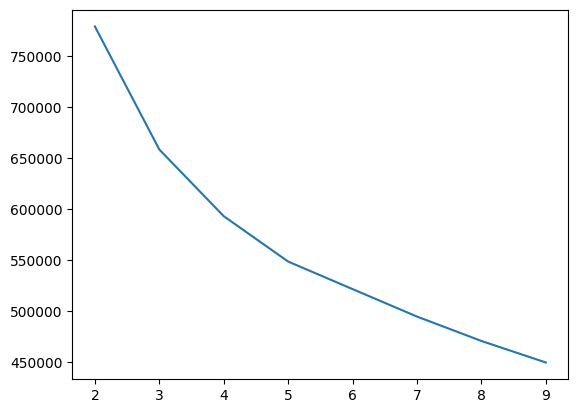

In [348]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
inertia=[]
for i in range(2,10):
    kmeans=KMeans(n_clusters=i,random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(range(2,10),inertia)
plt.show()

In [349]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)
pca_data_fit=pca.fit(X)
pca_data_transform=pca.transform(X)


In [350]:
import joblib
joblib.dump(pca_data_fit,"pca_data_fit.pkl")
joblib.dump(pca_data_transform,"pca_data_transform.pkl")

['pca_data_transform.pkl']

In [351]:
kmeans=KMeans(n_clusters=3,random_state=42)
model=kmeans.fit(X)
kmeans_cluster=kmeans.fit_predict(X)

In [352]:
import joblib
joblib.dump(model,"model.pkl")
joblib.dump(scaled_fit,"scalar.pkl")
joblib.dump(kmeans_cluster,"kmeans_cluster.pkl")

['kmeans_cluster.pkl']

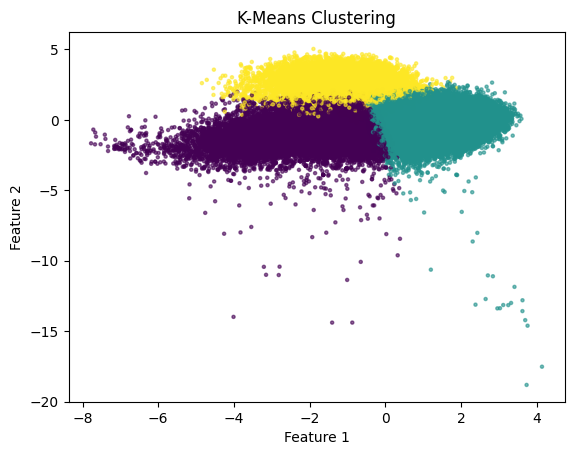

In [353]:
plt.scatter(pca_data_transform[:,0], pca_data_transform[:,1], c=kmeans_cluster, cmap='viridis',s=5,alpha=0.6)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('K-Means Clustering')
plt.show()

In [354]:
from sklearn.metrics import silhouette_score,davies_bouldin_score
SIL_score_Kmeans=silhouette_score(X,kmeans_cluster) # 3=0.2408, 5=0.1862, 7=0.1638, 10=0.1436,12=0.1544
print("SIL_score_Kmeans :",SIL_score_Kmeans)
Dav_score_kmean=davies_bouldin_score(X,kmeans_cluster) # 3=1.572, 5=1.668, 7=1.626, 10=1.674, 12=1.548
print("Dav_score_kmean :",Dav_score_kmean)

SIL_score_Kmeans : 0.24240141740662008
Dav_score_kmean : 1.5699416879877057


In [355]:
data["cluster"]=pd.Series(kmeans_cluster)
X["cluster"]=pd.Series(kmeans_cluster)

In [356]:
cluster=pd.DataFrame()
cluster["cluster"]=pd.Series(kmeans_cluster)
cluster["cluster"]=cluster["cluster"].map({2:"Label 2",1:"Label 1",0:"Label 0"})
cluster_count = cluster.groupby("cluster")["cluster"].count().reset_index(name="Count")
cluster_count

,cluster,Count
0,Label 0,30762
1,Label 1,52560
2,Label 2,12515


<BarContainer object of 3 artists>

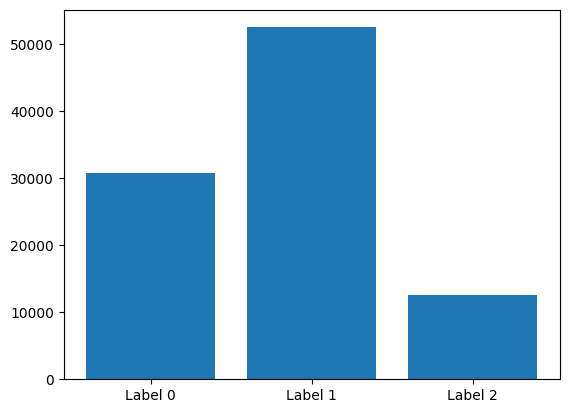

In [357]:
plt.bar(x=cluster_count["cluster"],height=cluster_count["Count"])

In [358]:
data.to_csv("Data_predicted.csv",index=False)
data

,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,cluster
0,161427,0.563,0.1840,4,-13.757,1,0.0512,0.993,0.000016,0.3250,0.654,133.088,3,0
1,223440,0.427,0.1800,10,-15.375,1,0.0670,0.989,0.000000,0.1280,0.431,78.459,3,0
2,208267,0.511,0.2060,0,-15.514,1,0.0592,0.995,0.000000,0.4180,0.481,70.443,4,0
3,161933,0.676,0.4670,9,-12.393,0,0.1650,0.991,0.000000,0.2190,0.726,129.775,4,0
4,167973,0.650,0.2980,9,-13.806,1,0.1380,0.991,0.000000,0.3730,0.844,75.950,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95832,174800,0.674,0.5680,1,-6.356,1,0.0408,0.116,0.000000,0.1650,0.640,166.107,4,1
95833,265846,0.528,0.6730,4,-3.639,1,0.0314,0.143,0.000000,0.0989,0.297,130.066,4,1
95834,82500,0.609,0.0172,8,-28.573,1,0.1180,0.996,0.973000,0.1080,0.890,68.619,4,0
95835,185250,0.562,0.0331,1,-25.551,1,0.1030,0.996,0.961000,0.1110,0.386,63.696,3,0


In [359]:
cluster_profile=data.groupby(data["cluster"]).mean().reset_index()

In [360]:
cluster_profile

,cluster,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,0,223500.904818,0.486242,0.311018,5.135427,-13.208988,0.674794,0.060103,0.749539,0.168760,0.182065,0.413047,111.933323,3.793089
1,1,226568.204680,0.627309,0.693465,5.273269,-7.608616,0.630803,0.075061,0.258713,0.050681,0.199854,0.666324,124.905464,3.948839
2,2,97522.338234,0.664254,0.466617,5.026368,-13.364383,0.654894,0.829908,0.585922,0.001384,0.435498,0.584036,100.387090,3.585218


In [361]:
X.to_csv("Data_predicted.csv",index=False)
X

,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,cluster
0,-0.401735,-0.153476,-1.511128,-0.757909,-0.427109,1.616187,-0.353338,0.538584,0.321287,0.515005,0
1,0.124906,-1.028518,-1.528056,-1.098629,-0.369741,1.604081,-0.353405,-0.521537,-0.577455,-1.294487,0
2,-0.003949,-0.488051,-1.418027,-1.127899,-0.398062,1.622240,-0.353405,1.039046,-0.375943,-1.560003,0
3,-0.397437,0.573581,-0.313510,-0.470677,-0.013914,1.610134,-0.353405,-0.031836,0.611464,0.405268,0
4,-0.346143,0.406294,-1.028695,-0.768227,-0.111948,1.610134,-0.353405,0.796887,1.087031,-1.377593,0
...,...,...,...,...,...,...,...,...,...,...,...
95832,-0.288165,0.560713,0.113908,0.800599,-0.464870,-1.038056,-0.353405,-0.322428,0.264864,1.608703,1
95833,0.485036,-0.378671,0.558254,1.372746,-0.499000,-0.956340,-0.353405,-0.678133,-1.117507,0.414907,1
95834,-1.072017,0.142494,-2.217003,-3.877872,-0.184566,1.625267,3.832648,-0.629163,1.272422,-1.620420,0
95835,-0.199419,-0.159910,-2.149717,-3.241498,-0.239029,1.625267,3.781021,-0.613019,-0.758816,-1.783486,0


In [362]:
scaled_profile=X.groupby(X["cluster"]).mean().reset_index()

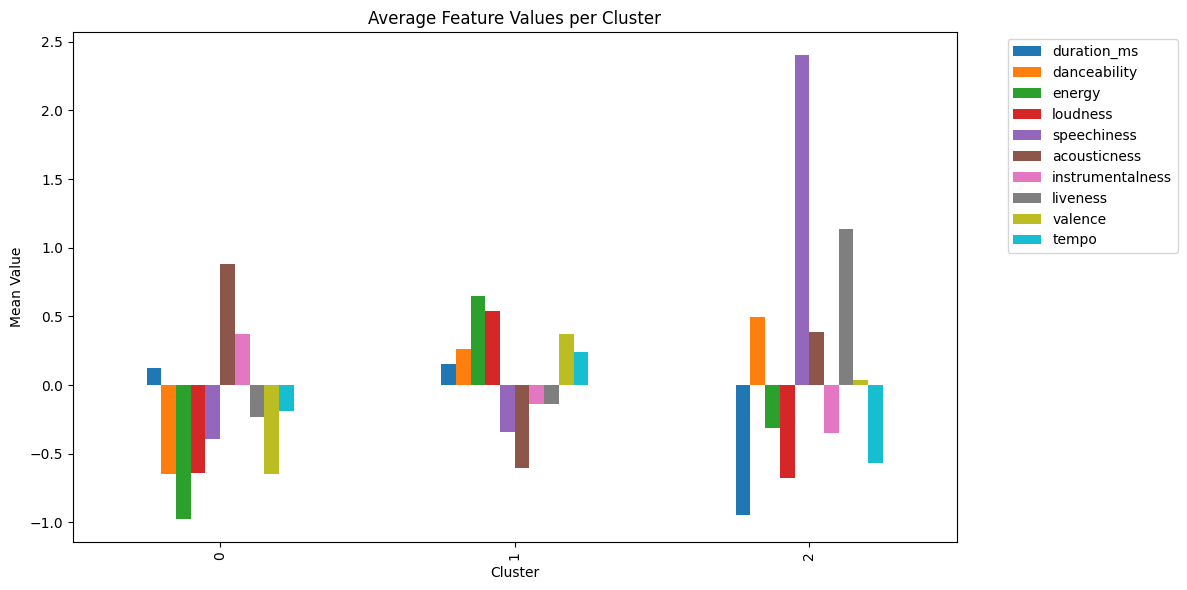

In [363]:
import matplotlib.pyplot as plt

# assuming 'cluster_profile' is the mean of each feature per cluster
scaled_profile.set_index('cluster').plot(kind='bar', figsize=(12,6))
plt.title("Average Feature Values per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Mean Value")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

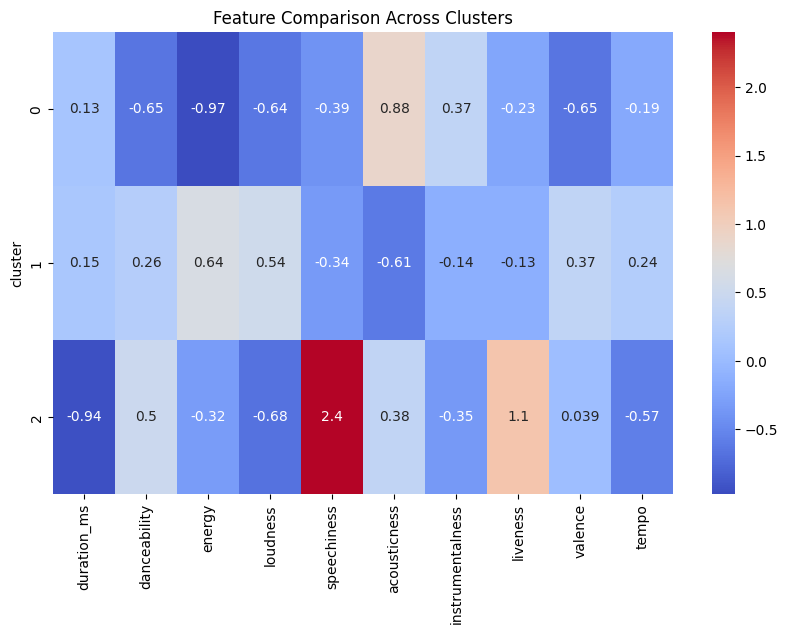

In [364]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(scaled_profile.set_index('cluster'), annot=True, cmap='coolwarm')
plt.title("Feature Comparison Across Clusters")
plt.show()

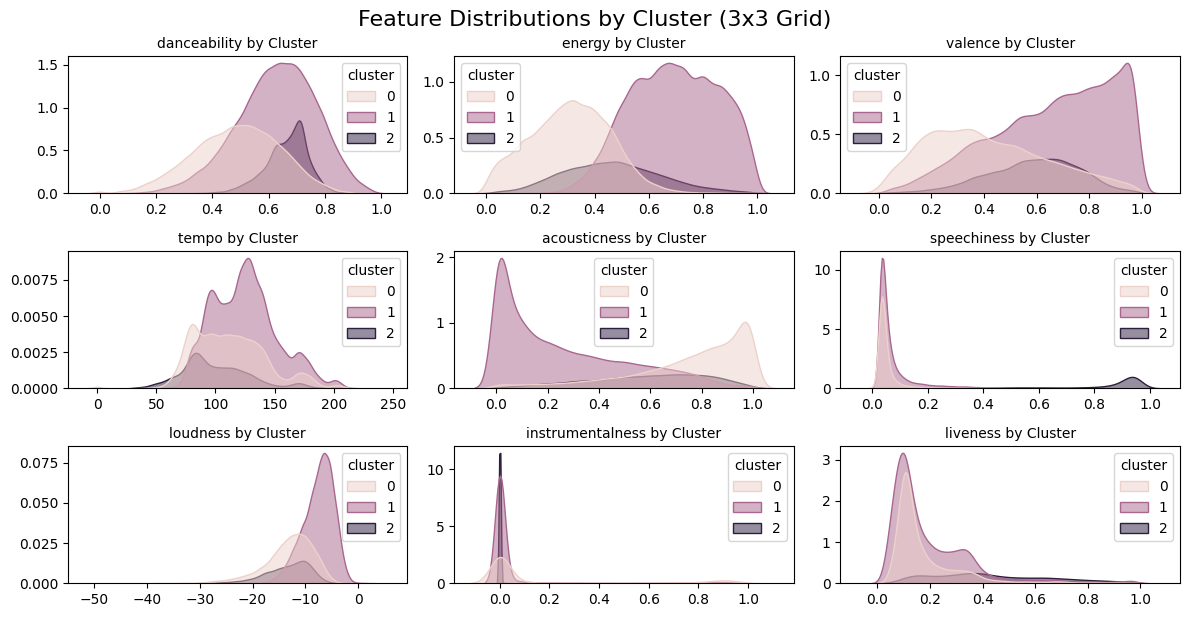

In [365]:
features = ['danceability', 'energy', 'valence', 'tempo', 
            'acousticness', 'speechiness', 'loudness', 
            'instrumentalness', 'liveness']

plt.figure(figsize=(12, 6))

for i, feature in enumerate(features, 1):
    plt.subplot(3, 3, i)
    sns.kdeplot(data=data, x=feature, hue='cluster', fill=True, alpha=0.5)
    plt.title(f"{feature} by Cluster", fontsize=10)
    plt.xlabel("")
    plt.ylabel("")
    plt.tight_layout()

plt.suptitle("Feature Distributions by Cluster (3x3 Grid)", fontsize=16, y=1.02)
plt.show()

In [366]:
original_data["genre"]=pd.Series(kmeans_cluster)
original_data["cluster"]=pd.Series(kmeans_cluster)

In [367]:
# Naming the cluster
original_data["genre"]=original_data["genre"].map({2:"Rap / Hip-Hop / Spoken-word",1:"Pop / Dance / Electronic",0:"Acoustic / Ballad / Indie"})

In [368]:
# Exporting the data with cluster
original_data.to_csv("prediction_in_original.csv",index=False)
original_data

,id_songs,name_song,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,...,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists,genre,cluster
0,0IA0Hju8CAgYfV1hwhidBH,La Java,0,161427,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.563,0.1840,4,...,0.3250,0.654,133.088,3,5078.0,['vintage chanson'],Mistinguett,22,Acoustic / Ballad / Indie,0
1,1b8HZQCqcqwbzlA1jRTp6E,En Douce,0,223440,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.427,0.1800,10,...,0.1280,0.431,78.459,3,5078.0,['vintage chanson'],Mistinguett,22,Acoustic / Ballad / Indie,0
2,5d5gQxHwYovxR5pqETOIAa,J'en Ai Marre,0,208267,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.511,0.2060,0,...,0.4180,0.481,70.443,4,5078.0,['vintage chanson'],Mistinguett,22,Acoustic / Ballad / Indie,0
3,1EO65UEEPfy7CR0NK2sDxy,Ils n'ont pas ca,0,161933,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.676,0.4670,9,...,0.2190,0.726,129.775,4,5078.0,['vintage chanson'],Mistinguett,22,Acoustic / Ballad / Indie,0
4,6a58gXSgqbIsXUhVZ6ZJqe,La belote,0,167973,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.650,0.2980,9,...,0.3730,0.844,75.950,4,5078.0,['vintage chanson'],Mistinguett,22,Acoustic / Ballad / Indie,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95832,44r4zta6P9flkhKaVnbsvG,Freaks,70,174800,0,14Y3trk7LaslSFTk1G35rx,2019-02-25,0.674,0.5680,1,...,0.1650,0.640,166.107,4,16057.0,['alt z'],Jordan Clarke,56,Pop / Dance / Electronic,1
95833,0MmaEacabpK8Yp3Mdeo5uY,下雨天,50,265846,0,5VGgFE9nPgMfEnYiPT5J2B,2020-02-25,0.528,0.6730,4,...,0.0989,0.297,130.066,4,929.0,['chinese viral pop'],芝麻,36,Pop / Dance / Electronic,1
95834,1dKxf4Ht2SsKLyXfSDJAgy,The Cutest Puppy,67,82500,0,7vgGpuiXdNlCmc994PlMlz,2020-10-30,0.609,0.0172,8,...,0.1080,0.890,68.619,4,23.0,['instrumental lullaby'],Laureen Conrad,52,Acoustic / Ballad / Indie,0
95835,0SjsIzJkZfDU7wlcdklEFR,John Brown's Song,66,185250,0,4MxqhahGRT4BPz1PilXGeu,2020-03-20,0.562,0.0331,1,...,0.1110,0.386,63.696,3,91.0,['instrumental lullaby'],Gregory Oberle,55,Acoustic / Ballad / Indie,0


In [369]:
print("*"*120)
print("*"*120)
print("                                             Model 2")
print("*"*120)
print("*"*120)

************************************************************************************************************************
************************************************************************************************************************
                                             Model 2
************************************************************************************************************************
************************************************************************************************************************


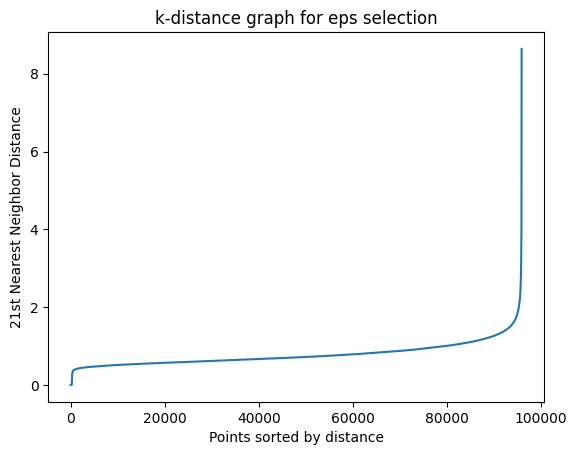

In [370]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
neigh = NearestNeighbors(n_neighbors=11)
nbrs = neigh.fit(X)
distances, indices = nbrs.kneighbors(X)

# Sort distances of the 10th nearest neighbor
distances = np.sort(distances[:, 4])
plt.plot(distances)
plt.xlabel('Points sorted by distance')
plt.ylabel('21st Nearest Neighbor Distance')
plt.title('k-distance graph for eps selection')
plt.show()


In [371]:
from sklearn.cluster import DBSCAN
DBS=DBSCAN(eps=0.9,min_samples=11) # by trail and error method
DBS_cluster=DBS.fit_predict(X)

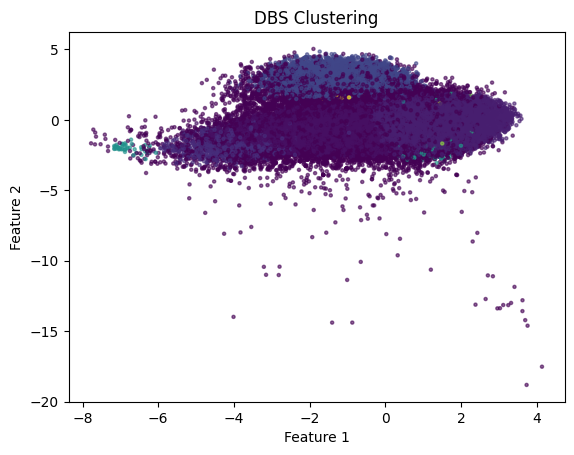

In [372]:
plt.scatter(pca_data_transform[:,0], pca_data_transform[:,1], c=DBS_cluster, cmap='viridis',s=5,alpha=0.6)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('DBS Clustering')
plt.show()

In [373]:
SIL_score_DBS=silhouette_score(X,DBS_cluster) 
print("SIL_score_DBS :",SIL_score_DBS)
Dav_score_DBS=davies_bouldin_score(X,DBS_cluster) 
print("Dav_score_DBS :",Dav_score_DBS)

SIL_score_DBS : -0.10130539521820052
Dav_score_DBS : 1.412319643202129
